=== ЗАВДАННЯ 1: Matplotlib Basics ===


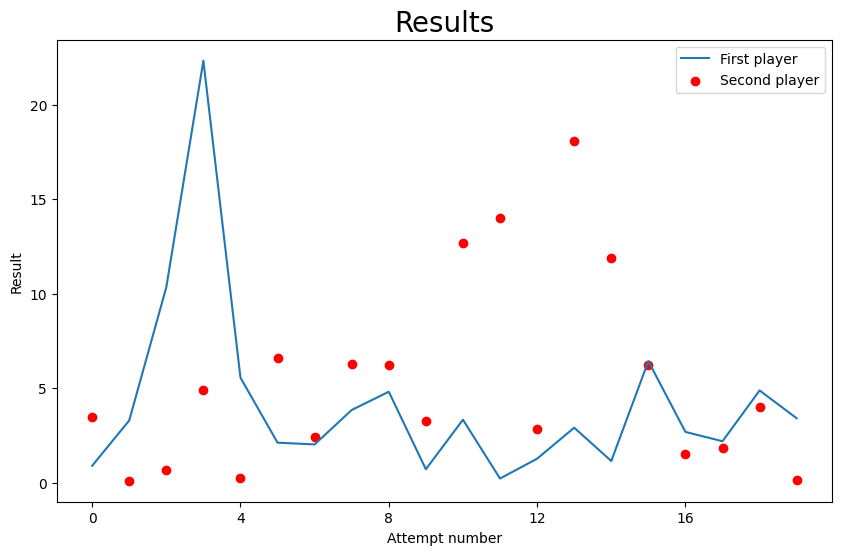

Графік 'results_task1.png' збережено.


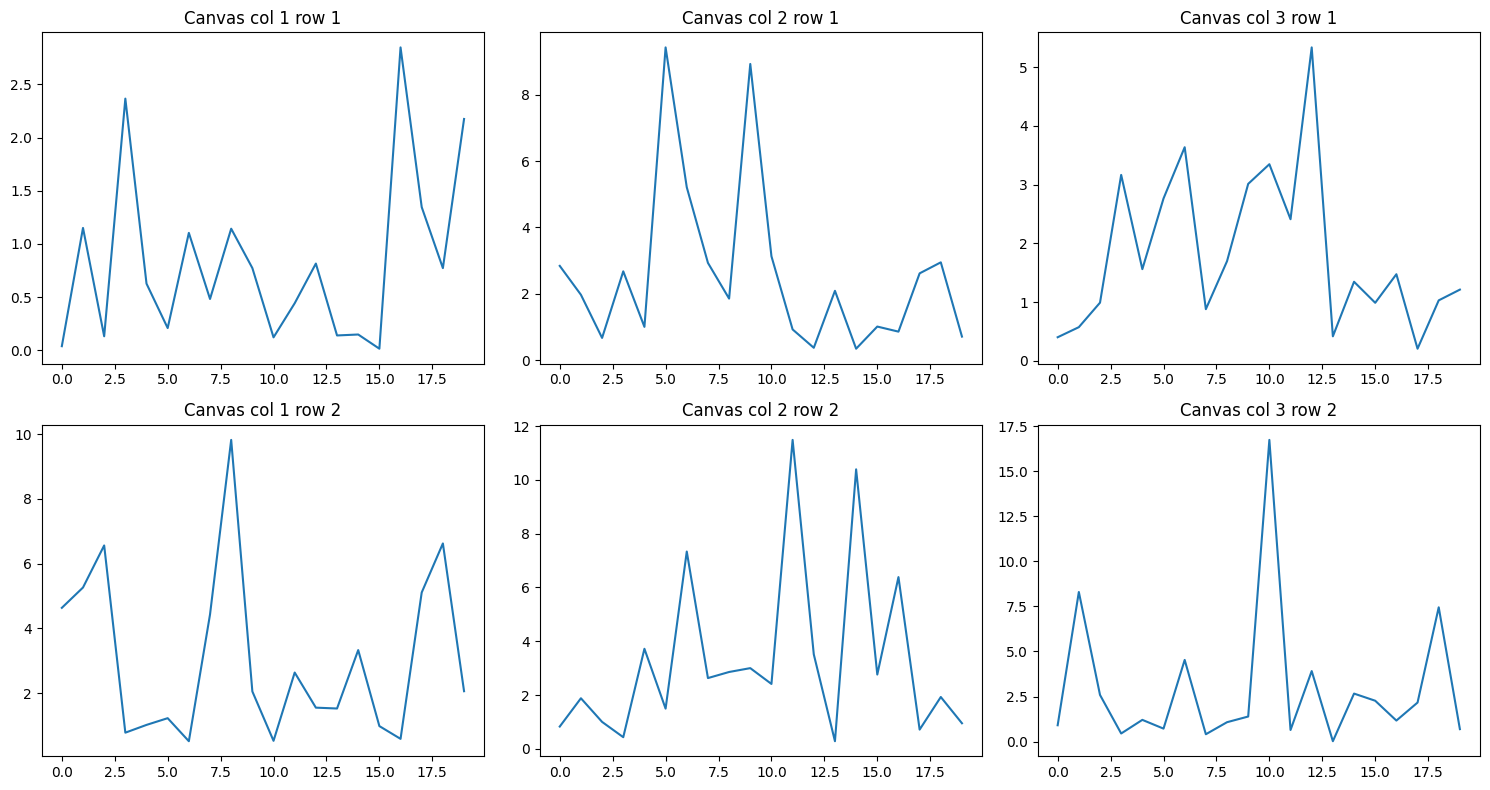

Графік 'all_results.png' збережено.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Налаштування для відображення графіків у Notebook [cite: 323]
%matplotlib inline

print("=== ЗАВДАННЯ 1: Matplotlib Basics ===")

# --- Генерація даних ---
# Використовуємо експоненціальний розподіл, як в методичці [cite: 335-336]
data1 = np.random.exponential(5, 20)
data2 = np.random.exponential(6, 20)

# --- Частина 1: Побудова простого графіку ---
plt.figure(figsize=(10, 6)) # Трохи збільшимо розмір

# Лінійний графік для data1 [cite: 337]
plt.plot(data1, label='First player')

# Точковий графік (scatter) для data2 з червоним кольором [cite: 340, 345, 358]
plt.scatter(range(len(data2)), data2, color='red', label='Second player')

# Налаштування текстових елементів
plt.title('Results', fontdict={'fontsize': 20}) # Заголовок [cite: 348, 351]
plt.xlabel('Attempt number') # Підпис осі X [cite: 353]
plt.ylabel('Result')         # Підпис осі Y [cite: 354]

# Налаштування поділок осі X (крок 4) [cite: 365]
plt.xticks(range(0, 20, 4))

# Легенда [cite: 362]
plt.legend()

# Збереження графіку у файл [cite: 369]
plt.savefig('results_task1.png')
plt.show()
print("Графік 'results_task1.png' збережено.")


# --- Частина 2: Subplots (Розширена візуалізація) ---
# Створення сітки графіків: 2 рядки, 3 колонки [cite: 391, 393]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

# Цикл по всіх осях для побудови графіків [cite: 400-403]
for row_idx, row_axes in enumerate(axes):
    for col_idx, ax in enumerate(row_axes):
        # Генеруємо різні дані для кожного графіку
        data_sub = np.random.exponential(col_idx + 1 + row_idx, 20)
        
        ax.plot(data_sub)
        ax.set_title('Canvas col {} row {}'.format(col_idx+1, row_idx+1))

# Компактне розміщення елементів [cite: 406]
fig.tight_layout()

# Збереження мульти-графіку [cite: 409]
fig.savefig('all_results.png')
plt.show()
print("Графік 'all_results.png' збережено.")

Датасет успішно завантажено!


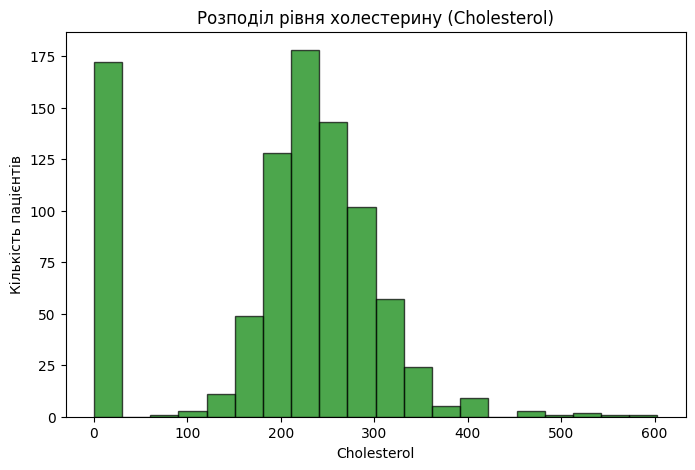

<Figure size 800x500 with 0 Axes>

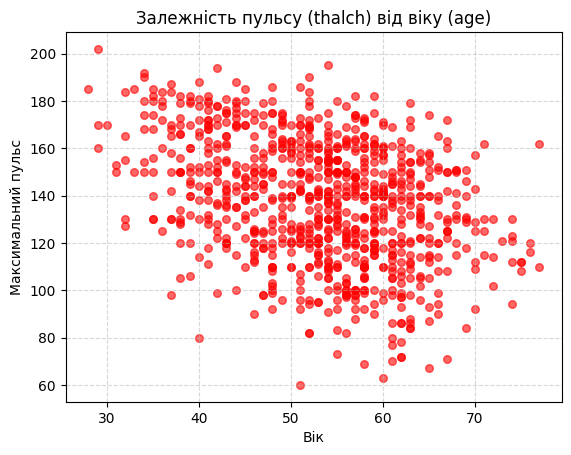

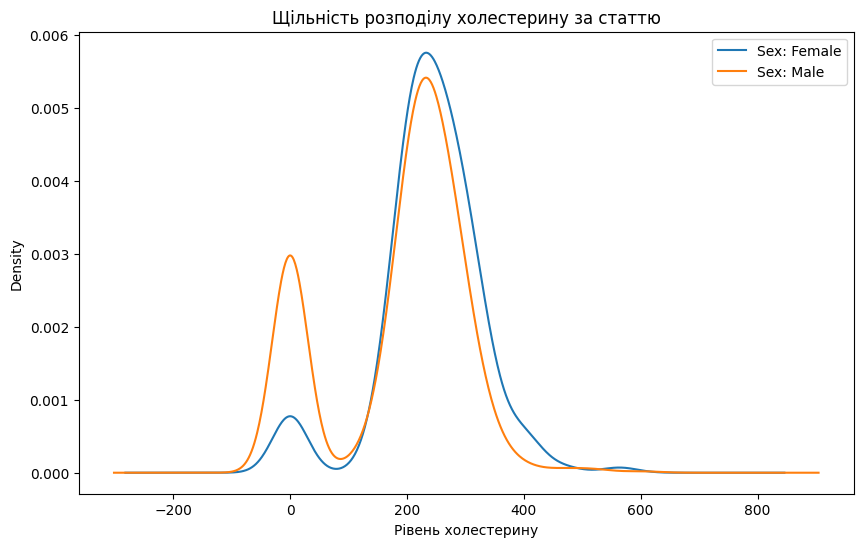

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Завантаження (переконайтесь, що файл називається heart.csv)
try:
    df = pd.read_csv('heart.csv')
    print("Датасет успішно завантажено!")
except FileNotFoundError:
    print("Помилка: Файл heart.csv не знайдено.")

# --- ВІЗУАЛІЗАЦІЯ ---

# [cite_start]1. Гістограма розподілу Холестерину (chol) [cite: 425-430]
# Використовуємо колонку 'chol' з вашого списку
plt.figure(figsize=(8, 5))
df['chol'].plot.hist(bins=20, color='green', edgecolor='black', alpha=0.7)
plt.title('Розподіл рівня холестерину (Cholesterol)')
plt.xlabel('Cholesterol')
plt.ylabel('Кількість пацієнтів')
plt.show()

# [cite_start]2. Scatter Plot: Вік (age) проти Пульсу (thalch) [cite: 435-438]
# ВИПРАВЛЕНО: використовуємо 'thalch' замість 'thalach'
plt.figure(figsize=(8, 5))
df.plot.scatter(x='age', y='thalch', c='red', alpha=0.6, s=30)
plt.title('Залежність пульсу (thalch) від віку (age)')
plt.xlabel('Вік')
plt.ylabel('Максимальний пульс')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# [cite_start]3. KDE + Групування: Холестерин у чоловіків та жінок [cite: 445-450]
# Використовуємо колонку 'sex' для групування
fig, ax = plt.subplots(figsize=(10, 6))

for label, class_df in df.groupby('sex'):
    # label у цьому датасеті може бути 'Male'/'Female' або 1/0
    class_df['chol'].plot.kde(ax=ax, label=f"Sex: {label}")

plt.title('Щільність розподілу холестерину за статтю')
plt.xlabel('Рівень холестерину')
plt.legend()
plt.show()

In [5]:
import pandas as pd
import plotly.graph_objs as go
import plotly.offline as offline

# 1. Ініціалізація Plotly для Notebook [cite: 486]
offline.init_notebook_mode(connected=True)

print("=== ЗАВДАННЯ 3: Plotly (World Happiness) ===")

# 2. Завантаження даних
# Завантажте архів з Kaggle за посиланням вище і візьміть файл 2019.csv
try:
    df = pd.read_csv('2019.csv')
    print("Датасет 'World Happiness 2019' успішно завантажено.")
except FileNotFoundError:
    print("Помилка: Файл '2019.csv' не знайдено. Будь ласка, завантажте його з Kaggle.")

# Огляд даних, щоб перевірити назви колонок
print(df.head())

# 3. Створення інтерактивного графіка (Trace) [cite: 500-502]
# У цьому датасеті немає континенту, тому побудуємо один загальний графік,
# але розфарбуємо точки в залежності від рівня щастя (Score).

trace = go.Scatter(
    x = df['GDP per capita'],          # Економічний показник
    y = df['Score'],                   # Соціальний показник (Щастя)
    mode = 'markers',                  # Режим точок [cite: 531]
    text = df['Country or region'],    # Назва країни при наведенні [cite: 540]
    marker = dict(
        # Розмір точки залежить від тривалості життя (множимо на коефіцієнт для масштабу)
        size = df['Healthy life expectancy'] * 30, 
        
        # Колір залежить від рейтингу щастя
        color = df['Score'], 
        colorscale = 'Viridis', # Кольорова гама
        showscale = True,       # Показати шкалу кольорів збоку
        opacity = 0.8
    )
)

# 4. Налаштування макету (Layout) і відображення
data = [trace]

layout = go.Layout(
    title = 'World Happiness Report: GDP vs Happiness Score (2019)',
    xaxis = dict(title = 'GDP per Capita (Relative)'),
    yaxis = dict(title = 'Happiness Score'),
    hovermode = 'closest'
)

fig = go.Figure(data=data, layout=layout)

# Відображення графіка [cite: 507]
offline.iplot(fig)

=== ЗАВДАННЯ 3: Plotly (World Happiness) ===
Датасет 'World Happiness 2019' успішно завантажено.
   Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.769           1.340           1.587   
1             2           Denmark  7.600           1.383           1.573   
2             3            Norway  7.554           1.488           1.582   
3             4           Iceland  7.494           1.380           1.624   
4             5       Netherlands  7.488           1.396           1.522   

   Healthy life expectancy  Freedom to make life choices  Generosity  \
0                    0.986                         0.596       0.153   
1                    0.996                         0.592       0.252   
2                    1.028                         0.603       0.271   
3                    1.026                         0.591       0.354   
4                    0.999                         0.557       0.322   

   Perception